# İST266 - Hipotez Testleri Proje Ödevi

> Bu dosyada istatistiksel analizleri ve cevapları içermeyecek sadece kodlama kısmı olacak.

Kullanılıcak dağılım ;

$X \sim N(\mu=50,\sigma^2=100)$

Bu dağılım kullanarak $N=10.000$ büyüklüğünde bir kitle oluşturmamız isteniyor.

In [98]:
import numpy as np
import matplotlib.pyplot as plt # Daha sonra kullanma için

rng = np.random.default_rng(seed=26)
kitle = rng.normal(loc=50, scale=10, size=10000)
print(kitle)

[30.74935502 19.81204769 61.54463147 ... 60.36609293 49.42113287
 41.62076388]


> NOT : Her seferinde yeniden oluşturuyordu bu yüzden bir dosyaya kaydedip oradan çekmeye çalıştım ancak bu sefer de her seferinde yeniden aynı dosyayı oluşturuyor ve içerisinde yeni değerleri kaydediyordu bu yüzden os kütüphanesini kullanarak dosya var ise yeniden oluşturmamasını sadece o kitle değerlerimizi içeren dosyamızı çağırmamızı sağladım.
> Bu yöntemden de vazgeçtim çünkü ödevin daha sonraki kısımlarında 

# ÖDEV 1

## Bölüm 1 - Kitle Parametrelerinin Hesaplanması

Oluşturduğumuz veri kümesini kitle olarak kabul edelim ve **kitle ortalaması**, **kitle varyansı** istatistiklerini hesaplayalım : 

In [99]:
kitle_ort = np.mean(kitle)
print(f"Kitle Ortalaması = {kitle_ort}")

Kitle Ortalaması = 50.10651655016294


Kitle varyansı = $\sigma^2 = \frac {\sum(Xi-\mu)^2}{N}$ 
(bknz. İst. Yönt. Giriş 61.sf)

In [118]:
var_kitle = np.var(kitle)
print(f"Kitle Varyansı = {var_kitle}")

Kitle Varyansı = 99.12312792831453


## Bölüm 2 - Farklı Örneklem Büyüklükleri ile Nokta Tahmini

Oluşturduğumuz kitleden;
 - n=10 , n=30, n=100, n=500
büyüklüklerinde örneklemler çkmemiz isteniyor.

> NOT : Aslında bu örneklemleri de ayrı dosyalar halinde tutacaktım ancak bölüm 3 de tutarlılık testi için 1000 adet örneklem ortalaması tekrarlattırıyor 1000 ayrı dosya şeklinde yapamam bu yüzden örneklem çekme aşamasında kitle kadar sabit olmadığından seed ile kitlemden örneklem çektiricem. Kitle için seed seçmeme sebebim yeterince random olduğunu düşünmememdi ancak mecbur örneklemler için seed mantığı ile gideceğim.

In [101]:
sample1 = rng.choice(kitle, size=10)
sample2 = rng.choice(kitle, size=30)
sample3 = rng.choice(kitle, size=100)
sample4 = rng.choice(kitle, size=500)

X'in dağılımının parametrelerine ait nokta tahmini için neler kullanırsınız? **Elde ettiğiniz tahminleri kitle paramtreleri ile karşılaştırınız.**

X'in dağılımı normal dağılım bu yüzden parametre tahminleri için : 
* ortalama parametresi için $\overline{x}$ (x ortalamayı)
* Varyans parametresi içinde $S^2$ (örneklem ortalması),
kullanırdım.

Bu tahmin değerlerini hesaplayıp kitle parametreleri ile karşılaştıralım.

$\overline{x} = \frac{\sum xi}{n}$

In [102]:
ort_sample1 = np.mean(sample1)
print(f"1.örneklem için X ortalama = {ort_sample1}")
ort_sample2 = np.mean(sample2)
print(f"2.örneklem için X ortalama = {ort_sample2}")
ort_sample3 = np.mean(sample3)
print(f"3.örneklem için X ortalama = {ort_sample3}")
ort_sample4 = np.mean(sample4)
print(f"4.örneklem için X ortalama = {ort_sample4}")

1.örneklem için X ortalama = 51.23863490214186
2.örneklem için X ortalama = 49.768142057628886
3.örneklem için X ortalama = 50.045342377970684
4.örneklem için X ortalama = 50.80455027187787


$S^2 = \frac{\sum (xi - \overline{X})^2}{n-1}$

In [103]:
var_sample1 = np.var(sample1, ddof=1)
print(f"1.örneklem için örneklem varyansı = {var_sample1}")
var_sample2 = np.var(sample2, ddof=1)
print(f"2.örneklem için örneklem varyansı = {var_sample2}")
var_sample3 = np.var(sample3, ddof=1)
print(f"3.örneklem için örneklem varyansı = {var_sample3}")
var_sample4 = np.var(sample4, ddof=1)
print(f"4.örneklem için örneklem varyansı = {var_sample4}")

1.örneklem için örneklem varyansı = 65.14485914208004
2.örneklem için örneklem varyansı = 48.99186399951632
3.örneklem için örneklem varyansı = 91.00381011345227
4.örneklem için örneklem varyansı = 105.47933129173595


Çıkan sonuçlarımıza göre karşılaştırıp yorum yapacak olursam; örneklem büyüklüğü arttıkça varyans için kitlenin varyansına yakınlaştığını görebliyorum. Ortalama için ise en yakın değerin örneklem büyüklüğü en fazla olan örneklem olduğunu yorumlayabilirim.

## Bölüm 3 - Yansızlık ve Tutarlılık Simülasyonu

In [104]:
n10_means = []
n30_means = []
n100_means = []
n500_means = []

for i in range(1000):
    sample10 = rng.choice(kitle,size=10)
    n10_means.append(np.mean(sample10))
    
    sample30 = rng.choice(kitle,size=30)
    n30_means.append(np.mean(sample30))
    
    sample100 = rng.choice(kitle,size=100)
    n100_means.append(np.mean(sample100))

    sample500 = rng.choice(kitle,size=500)
    n500_means.append(np.mean(sample500))



In [121]:
print(f"n = 10 için örneklem ortalamalarının ortalaması : {np.mean(n10_means)}, Varyansı : {np.var(n10_means,ddof=1)}")
print(f"n = 30 için örneklem ortalamalarının ortalaması : {np.mean(n30_means)}, Varyansı : {np.var(n30_means,ddof=1)}")
print(f"n = 100 için örneklem ortalamalarının ortalaması : {np.mean(n100_means)}, Varyansı : {np.var(n100_means,ddof=1)}")
print(f"n = 500 için örneklem ortalamalarının ortalaması : {np.mean(n500_means)}, Varyansı : {np.var(n500_means,ddof=1)}")

n = 10 için örneklem ortalamalarının ortalaması : 50.033594742042666, Varyansı : 9.98346703401207
n = 30 için örneklem ortalamalarının ortalaması : 50.077417967920056, Varyansı : 3.3405473241528965
n = 100 için örneklem ortalamalarının ortalaması : 50.11983083020773, Varyansı : 0.9733018129139838
n = 500 için örneklem ortalamalarının ortalaması : 50.099973242594444, Varyansı : 0.18687106718520716


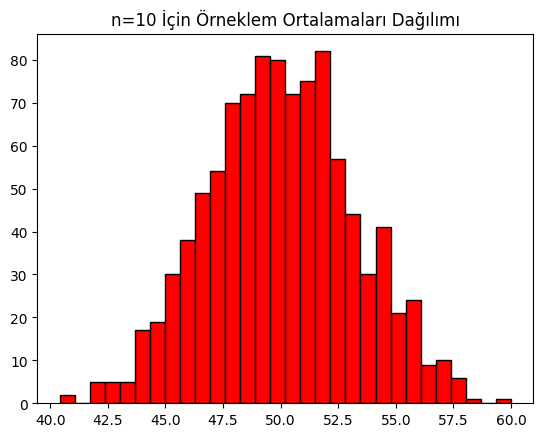

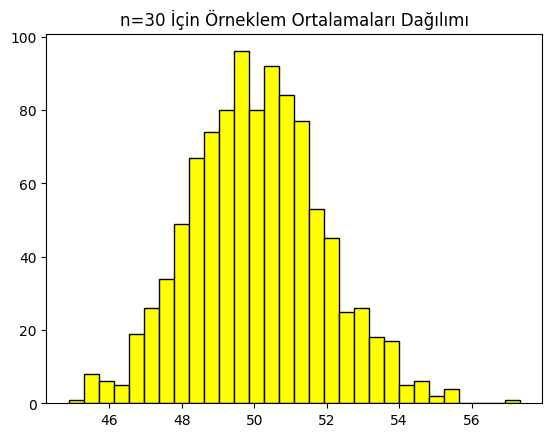

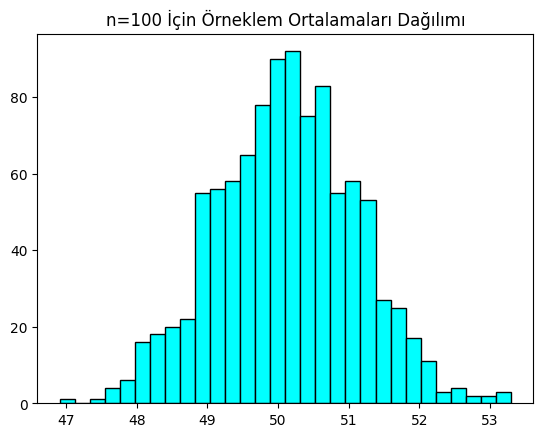

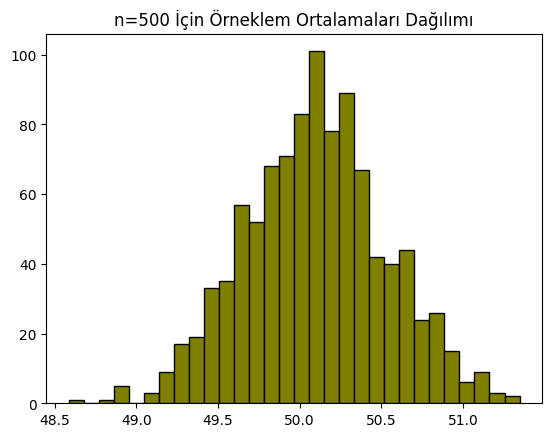

In [122]:
plt.hist(n10_means, bins=30, color="red", edgecolor="black")
plt.title("n=10 İçin Örneklem Ortalamaları Dağılımı")
plt.show()

plt.hist(n30_means, bins=30, color="yellow", edgecolor="black")
plt.title("n=30 İçin Örneklem Ortalamaları Dağılımı")
plt.show()

plt.hist(n100_means, bins=30, color="cyan", edgecolor="black")
plt.title("n=100 İçin Örneklem Ortalamaları Dağılımı")
plt.show()

plt.hist(n500_means, bins=30, color="olive", edgecolor="black")
plt.title("n=500 İçin Örneklem Ortalamaları Dağılımı")
plt.show()

# ÖDEV 2


In [123]:
rng2 = np.random.default_rng(seed=26)

## Bölüm 1 - Simülasyon

In [124]:
t1_mu = []
t2_mu = []
t3_mu = []

for i in range(1000):
    sample = rng2.normal(loc=20,scale=15,size=30)
    
    t1 = np.mean(sample)
    t1_mu.append(t1)

    t2 = (sample[0]+sample[1])/2
    t2_mu.append(t2)

    t3 = (sample[0]-(2*sample[1])+(3*sample[2]))/6
    t3_mu.append(t3)

In [125]:
t1_sigma_sq = []
t2_sigma_sq = []

for i in range(1000):
    sample = rng2.normal(loc=20,scale=15,size=30)

    t1 = np.var(sample,ddof=1)
    t1_sigma_sq.append(t1)

    t2 = ((sample[0]-sample[1])**2)/2
    t2_sigma_sq.append(t2)

## Bölüm 2 - Tahmin Ediciler Performansı

In [126]:
# Yansızlık hesabı
"""
mü için ise t1 ve t2 yansız ancak t3 yanlı dır deriz aldığımız o t.e lere ait 
ortalamalar ortalaması bizi bu sonuca götürdü (beklenen değer parametreye eşit 
olmadığı görüldü)

varyans için se test ettiğmiz t1 ve t2 t.e (tahmin edicileri) varyanslarına ait 
örneklemimizin ortalamasını alarak nereye götrüdüğüne baktık ve ikisi de bizi 
dağılımımızıın varyansına götürdü bu iki t.e ye de yansız diyebildik.
"""
print(np.mean(t1_mu)-20)
print(np.mean(t2_mu)-20)
print(np.mean(t3_mu)-20)



print(np.mean(t1_sigma_sq)-20)
print(np.mean(t2_sigma_sq)-20)

-0.001714921444847306
0.342679087543754
-14.205737200259803
203.46722565597062
206.87207521551426


In [111]:
# varyansı 

t1_mu_var = np.var(t1_mu,ddof=1)
t2_mu_var = np.var(t2_mu,ddof=1)
t3_mu_var = np.var(t3_mu,ddof=1)

print(f"mu T1 t.e dağılımının varyansı = {t1_mu_var}")
print(f"mu T2 t.e dağılımının varyansı = {t2_mu_var}")
print(f"mu T3 t.e dağılımının varyansı = {t3_mu_var}")

t1_sigma_sq_var = np.var(t1_sigma_sq,ddof=1)
t2_sigma_sq_var = np.var(t2_sigma_sq,ddof=1)

print(f"sigma kare T1 t.e dağılımının varyansı = {t1_sigma_sq_var}")
print(f"sigma kare T2 t.e dağılımının varyansı = {t2_sigma_sq_var}")

mu T1 t.e dağılımının varyansı = 7.309909836875564
mu T2 t.e dağılımının varyansı = 112.96634767182057
mu T3 t.e dağılımının varyansı = 95.33227380212516
sigma kare T1 t.e dağılımının varyansı = 3324.480145242315
sigma kare T2 t.e dağılımının varyansı = 101224.10628780416


In [112]:
# Hata kareler ortalaması
t1_mu_yan = np.mean(t1_mu)-20
t2_mu_yan = np.mean(t2_mu)-20
t3_mu_yan = np.mean(t3_mu)-20

hko_t1_mu = t1_mu_var + t1_mu_yan**2
hko_t2_mu = t2_mu_var + t2_mu_yan**2
hko_t3_mu = t3_mu_var + t3_mu_yan**2

print(f" T1_mu t.e için HKO = {hko_t1_mu}")
print(f" T2_mu t.e için HKO = {hko_t2_mu}")
print(f" T3_mu t.e için HKO = {hko_t3_mu}")

t1_sigma_sq_yan = t1_sigma_sq_var-225
t2_sigma_sq_yan = t2_sigma_sq_var-225

hko_t1_sigma_sq = t1_sigma_sq_var + t1_sigma_sq_yan**2
hko_t2_sigma_sq = t2_sigma_sq_var + t2_sigma_sq_yan**2

print(f" T1_var t.e için HKO = {hko_t1_sigma_sq}")
print(f" T2_var t.e için HKO = {hko_t2_sigma_sq}")

 T1_mu t.e için HKO = 7.3099127778311255
 T2_mu t.e için HKO = 113.08377662886039
 T3_mu t.e için HKO = 297.1352432049704
 T1_var t.e için HKO = 9610101.650896564
 T2_var t.e için HKO = 10200920695.041449


## Bölüm 3 - Etkinlik

Uygun şartları sağlayan t.e etkinliğini hesaplayınız. (Hesaplarımıza göre sadece T3_mu t.e'miz yanlı olduğu için etkinliğini ölçemeyiz)

In [127]:
print(f"T2_mu'nin T1_mu'e etkinliği = {t1_mu_var/t2_mu_var}")

T2_mu'nin T1_mu'e etkinliği = 0.0647087383767743


In [128]:
print(f"T2_mu'nin T1_mu'e etkinliği = {t1_sigma_sq_var/t2_sigma_sq_var}")

T2_mu'nin T1_mu'e etkinliği = 0.032842771027190194


# ÖDEV 3


## Bölüm 1 - Simülasyon 

Test ettiğmiz tahmin edicimiz Xn yani  en büyük sıralı istatistik

In [129]:
Xnler = []
for i in range(10000):
    orneklem = np.random.uniform(low=0, high=10, size=30)
    Xnler.append(np.max(orneklem))
print(np.array(Xnler))

[9.73586936 9.24083776 9.78039627 ... 9.83991173 9.98925869 9.97336416]


## Bölüm 2 - Tahmin Edicinin Davranışı

In [116]:
Xnler_ort = np.mean(Xnler)
Xnler_var = np.var(Xnler)

print(f"Teta_sapka (Xn -En buyuk sıralı ist-) t.e'nin ortalaması = {Xnler_ort}")
print(f"Teta_sapka (Xn -En buyuk sıralı ist-) t.e'nin varyansı = {Xnler_var}")

Teta_sapka (Xn -En buyuk sıralı ist-) t.e'nin ortalaması = 9.684062344483591
Teta_sapka (Xn -En buyuk sıralı ist-) t.e'nin varyansı = 0.0956416150728507


<function matplotlib.pyplot.show(close=None, block=None)>

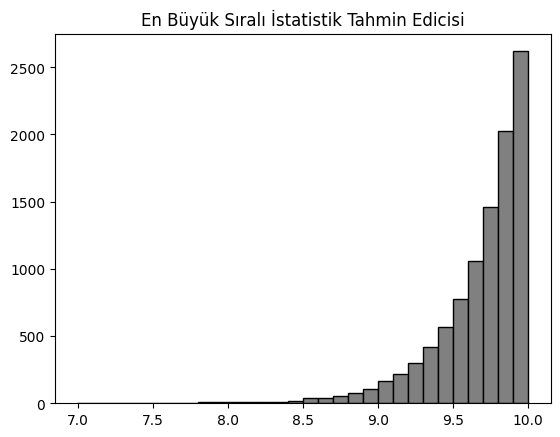

In [117]:
plt.hist(Xnler, bins=30, color="grey", edgecolor="black")
plt.title("En Büyük Sıralı İstatistik Tahmin Edicisi")
plt.show